# Demand EDA
This notebook explores demand patterns using groupby aggregations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('../../data/precomputed', exist_ok=True)
os.makedirs('../../frontend/public/data', exist_ok=True)

## Load Data
We load the necessary columns from the combined Instacart dataset.

In [2]:
cols = ['product_id', 'product_name', 'department', 'aisle', 'order_dow', 'order_hour_of_day']
df = pd.read_csv('../../data/combined_instacart_data.csv', usecols=cols)

## Total Orders per Day of Week
Which days see the most orders overall.

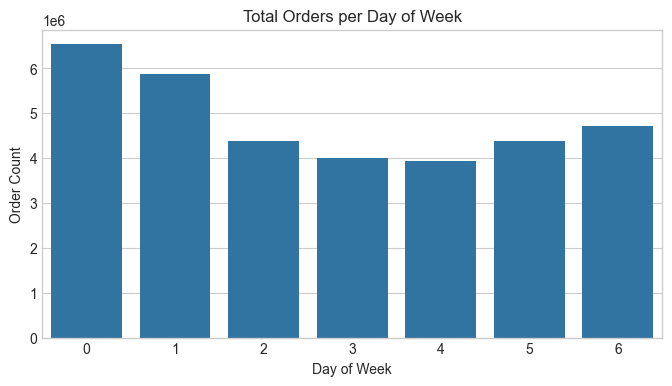

In [3]:
dow_counts = df['order_dow'].value_counts().sort_index().reset_index()
dow_counts.columns = ['order_dow', 'order_count']

plt.figure(figsize=(8,4))
sns.barplot(data=dow_counts, x='order_dow', y='order_count')
plt.title('Total Orders per Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Order Count')
plt.show()

dow_counts.to_csv('../../data/precomputed/orders_per_dow.csv', index=False)

## Order Volume by Hour of Day
Which hour of the day sees peak orders.

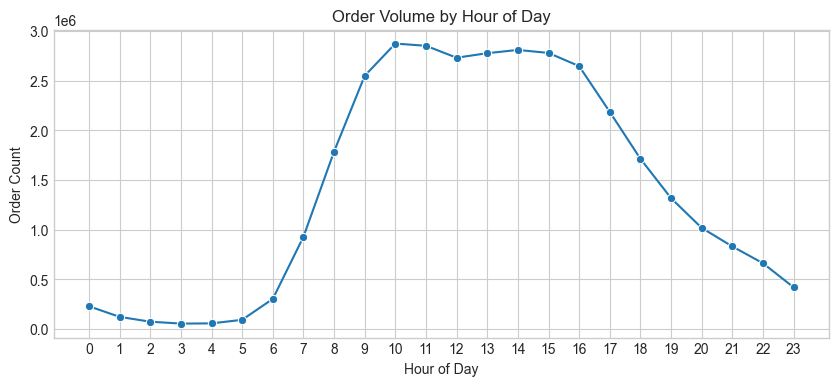

In [4]:
hour_counts = df['order_hour_of_day'].value_counts().sort_index().reset_index()
hour_counts.columns = ['order_hour_of_day', 'order_count']

plt.figure(figsize=(10,4))
sns.lineplot(data=hour_counts, x='order_hour_of_day', y='order_count', marker='o')
plt.title('Order Volume by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Order Count')
plt.xticks(range(0, 24))
plt.show()

hour_counts.to_csv('../../data/precomputed/orders_per_hour.csv', index=False)

## Department and Aisle Demand per DOW
Highest demand per department and aisle for each day of the week.

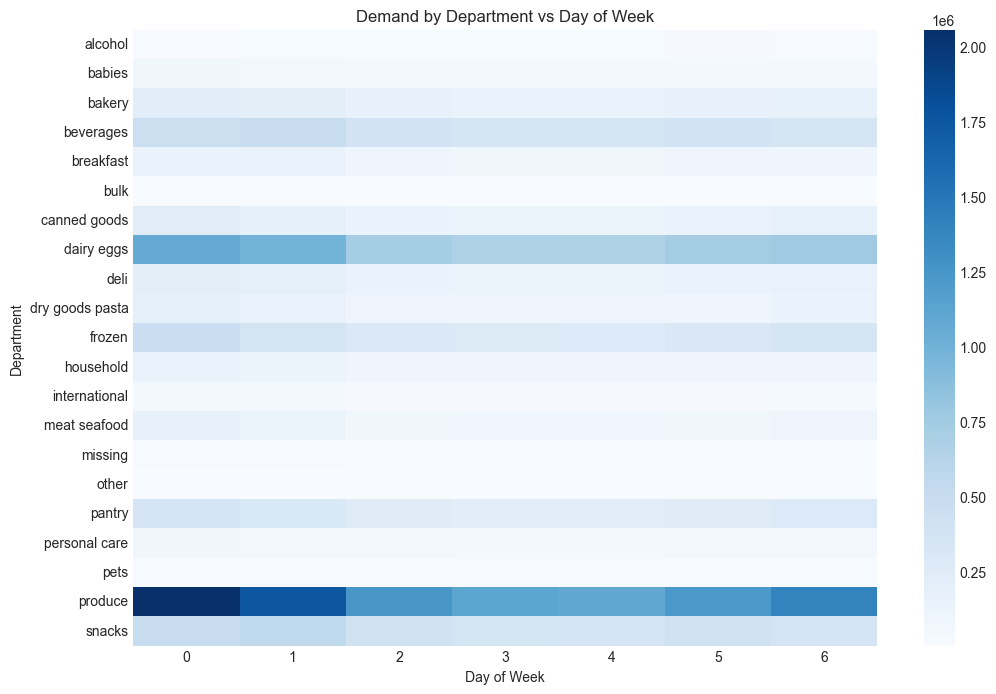

In [5]:
dept_dow = df.groupby(['department', 'order_dow']).size().reset_index(name='order_count')
# For visualization we pivot it
pivot_dept = dept_dow.pivot(index='department', columns='order_dow', values='order_count').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_dept, cmap='Blues')
plt.title('Demand by Department vs Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Department')
plt.show()

dept_dow.to_csv('../../data/precomputed/dept_demand_dow.csv', index=False)

## Top 10 Products per DOW
Finding the most ordered products for each day.

In [6]:
top_products_dow = df.groupby(['order_dow', 'product_name']).size().reset_index(name='order_count')
top_products_dow = top_products_dow.sort_values(['order_dow', 'order_count'], ascending=[True, False])
top_10_dow = top_products_dow.groupby('order_dow').head(10)

top_10_dow.to_csv('../../data/precomputed/top_products_dow.csv', index=False)

## Top 10 Products Overall
Overall top 10 most ordered products.

In [7]:
top_overall = df['product_name'].value_counts().head(10).reset_index()
top_overall.columns = ['product_name', 'order_count']
top_overall.to_csv('../../data/precomputed/top_products_overall.csv', index=False)

## Top 20 Aisles
Overall top 20 most ordered aisles.

In [ ]:
top_a = df['aisle'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
top_a.plot(kind='barh', ax=ax)
ax.invert_yaxis()
ax.set_xlabel('Order Count')
ax.set_title('Top 20 Aisles')
plt.tight_layout()
plt.show()

top_aisles = df['aisle'].value_counts().head(20).reset_index()
top_aisles.columns = ['aisle', 'order_count']
top_aisles.to_csv('../../data/precomputed/top_aisles.csv', index=False)